In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

In [ ]:
texts = [
    "This product is amazing",
    "I love this",
    "Very good quality",
    "This is bad",
    "I hate this",
    "Worst product ever"
]

labels = [1, 1, 1, 0, 0, 0]  # 1 = Positive, 0 = Negative

In [ ]:
vectorizer = layers.TextVectorization(max_tokens=1000)
vectorizer.adapt(texts)

X = vectorizer(texts)
y = np.array(labels)

In [ ]:
model = keras.Sequential([
    layers.Embedding(input_dim=1000, output_dim=16),
    layers.GlobalAveragePooling1D(),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # output 0 or 1
])

In [ ]:
model = keras.Sequential([
    layers.Embedding(input_dim=1000, output_dim=16),
    layers.GlobalAveragePooling1D(),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(X, y, epochs=10)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.6667 - loss: 0.6920
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8333 - loss: 0.6910
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.6901
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 1.0000 - loss: 0.6893
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 0.6884
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 0.6875
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 1.0000 - loss: 0.6867
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 1.0000 - loss: 0.6857
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 0.6848
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 0.6840


In [ ]:
loss, accuracy = model.evaluate(X, y)
print("Final Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 1.0000 - loss: 0.6831
Final Accuracy: 1.0


In [ ]:
model.fit(X, y, epochs=30)

Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 0.6831
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 1.0000 - loss: 0.6822
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 0.6813
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 0.6803
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 1.0000 - loss: 0.6792
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 1.0000 - loss: 0.6781
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 1.0000 - loss: 0.6770
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 1.0000 - loss: 0.6759
Epoch 9/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 0.6747
Epoch 10/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 0.6736
Epoch 11/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 0.6724
Epoch 12/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 0.6711
E

In [ ]:
def predict_text(text):
    input_data = vectorizer([text])
    prediction = model.predict(input_data)[0][0]

    if prediction > 0.5:
        label = "Positive"
    else:
        label = "Negative"

    confidence = prediction if prediction > 0.5 else 1 - prediction

    print(f"Text: {text}")
    print(f"Prediction: {label}")
    print(f"Confidence: {confidence*100:.2f}%")

In [ ]:
predict_text("This product is amazing")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Text: This product is amazing
Prediction: Positive
Confidence: 52.00%


In [ ]:
history = model.fit(X, y, epochs=10, validation_split=0.2)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 1.0000 - loss: 0.6457 - val_accuracy: 1.0000 - val_loss: 0.6406
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 1.0000 - loss: 0.6437 - val_accuracy: 1.0000 - val_loss: 0.6404
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 1.0000 - loss: 0.6413 - val_accuracy: 1.0000 - val_loss: 0.6407
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 1.0000 - loss: 0.6387 - val_accuracy: 1.0000 - val_loss: 0.6416
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 1.0000 - loss: 0.6359 - val_accuracy: 1.0000 - val_loss: 0.6429
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 1.0000 - loss: 0.6330 - val_accuracy: 1.0000 - val_loss: 0.6446
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 1.0000 - loss: 0.6300 - val_accuracy: 1.0000 - val_loss: 0.6466
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 1.0000 - loss: 0.6269 - val_accuracy: 1.0000 - val_loss: 0.6489

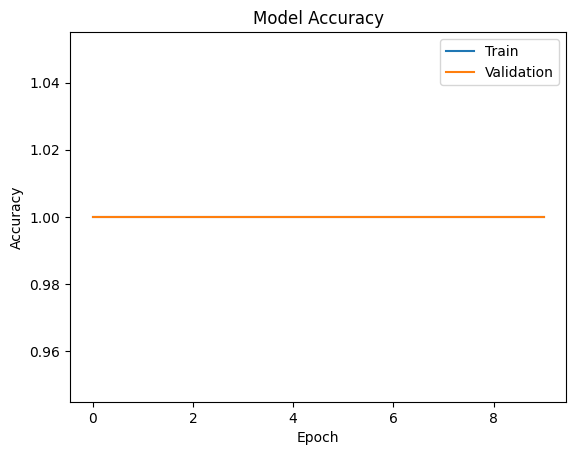

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()